
# Лабораторная работа №1
## Использование одного нейрона. Правило Хебба. Исследование функций активации.

**Студент:** Шрук Мохамед (Шрук — имя, Мохамед — отчество)
**Вариант:** буквы «Ш» и «М» (первые буквы имени и отчества)

**Цель работы:** закрепление теоретических знаний, получение практических навыков
использования одного нейрона, исследование правила Хебба, исследование функций активации.


In [1]:

# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)



## Часть 1. Правило Хебба

### 1.1 Разработка эталонных изображений

Разработаны два класса изображений размером 5x5 пикселей:

- **Класс 1** — буква **«Ш»** (первая буква имени) — 2 изображения
- **Класс 2** — буква **«М»** (первая буква отчества) — 2 изображения

Изображения внутри одного класса отличаются не более чем на 4 пикселя.


In [2]:

# Матрицы 5x5, 1 -- закрашенный (черный) пиксель, 0 -- фон (белый) пиксель

# ---- Класс 1: буква "Ш" (имя -- Шрук) ----
Sh_1 = np.array([
    [1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1],
    [1, 1, 1, 1, 1],
])

Sh_2 = np.array([
    [1, 0, 0, 0, 1],   # изменен пиксель (0,2): 1 -> 0
    [1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1],
    [0, 1, 1, 1, 1],   # изменен пиксель (4,0): 1 -> 0
])

# ---- Класс 2: буква "М" (отчество -- Мохамед) ----
M_1 = np.array([
    [1, 0, 0, 0, 1],
    [1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
])

M_2 = np.array([
    [1, 0, 0, 0, 1],
    [1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1],
    [1, 0, 1, 0, 1],   # изменен пиксель (3,2): 0 -> 1
    [0, 0, 0, 0, 1],   # изменен пиксель (4,0): 1 -> 0
])

# Проверка: количество различий внутри каждого класса должно быть <= 4
diff_class1 = np.sum(Sh_1 != Sh_2)
diff_class2 = np.sum(M_1 != M_2)
print(f"Различие внутри класса 1 (Ш1 vs Ш2): {diff_class1} пикселей")
print(f"Различие внутри класса 2 (М1 vs М2): {diff_class2} пикселей")
assert diff_class1 <= 4 and diff_class2 <= 4, "Условие задания нарушено!"


Различие внутри класса 1 (Ш1 vs Ш2): 2 пикселей
Различие внутри класса 2 (М1 vs М2): 2 пикселей


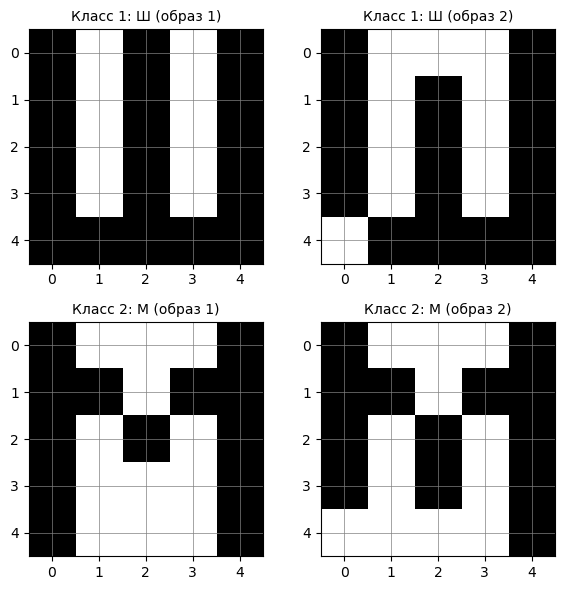

In [3]:

# Визуализация эталонных изображений
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
images = [Sh_1, Sh_2, M_1, M_2]
titles = ["Класс 1: Ш (образ 1)", "Класс 1: Ш (образ 2)",
          "Класс 2: М (образ 1)", "Класс 2: М (образ 2)"]

for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.grid(color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()



### 1.2 Структура нейросети

Используется **один нейрон** (Single Neuron) с:
- вектором входов $x \in \mathbb{R}^{25}$ (изображение 5x5, развернутое в вектор длиной 25),
- вектором весов $w \in \mathbb{R}^{25}$,
- смещением (bias) $b$,
- суммирующим блоком (net input): $net = w \cdot x + b$,
- функцией активации $f(net)$, выдающей класс изображения (+1 / -1 или 1 / 0).

Класс 1 («Ш») кодируется целевым значением $t=+1$, класс 2 («М») — $t=-1$.


In [4]:

# Разворачиваем матрицы 5x5 в вектора длиной 25 (flatten)

def to_binary_vector(img):
    '''Бинарное представление: пиксели остаются в {0, 1}'''
    return img.flatten().astype(float)

def to_bipolar_vector(img):
    '''Биполярное представление: 0 -> -1, 1 -> 1'''
    v = img.flatten().astype(float)
    return np.where(v == 0, -1.0, 1.0)

# Эталонные изображения в виде векторов (бинарное представление)
X_bin = np.array([
    to_binary_vector(Sh_1),
    to_binary_vector(Sh_2),
    to_binary_vector(M_1),
    to_binary_vector(M_2),
])

# Эталонные изображения в виде векторов (биполярное представление)
X_bip = np.array([
    to_bipolar_vector(Sh_1),
    to_bipolar_vector(Sh_2),
    to_bipolar_vector(M_1),
    to_bipolar_vector(M_2),
])

# Целевые значения (класс 1 -> +1, класс 2 -> -1) -- одинаковые для обоих представлений
targets = np.array([1, 1, -1, -1], dtype=float)

print("Форма X_bin:", X_bin.shape)   # (4, 25)
print("Форма X_bip:", X_bip.shape)   # (4, 25)
print("Целевые значения:", targets)


Форма X_bin: (4, 25)
Форма X_bip: (4, 25)
Целевые значения: [ 1.  1. -1. -1.]



### 1.3 Обучение нейрона по правилу Хебба

Правило Хебба для одного нейрона:

$$ w = \sum_{i} t_i \cdot x_i, \qquad b = \sum_i t_i $$

где $x_i$ — вектор i-го эталонного изображения, $t_i$ — его целевой класс (+1 или -1).


In [5]:

def train_hebb(patterns, targets):
    '''
    Обучение одного нейрона по правилу Хебба.
    patterns : ndarray, shape (N, n_features) -- обучающие образы
    targets  : ndarray, shape (N,)            -- целевые классы (+1 / -1)
    Возвращает: веса w (shape (n_features,)) и смещение b (float)
    '''
    n_features = patterns.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    for x, t in zip(patterns, targets):
        w += t * x        # Δw = t * x  (правило Хебба)
        b += t             # Δb = t
    return w, b

# Обучаем нейрон отдельно на бинарном и на биполярном представлении
w_bin, b_bin = train_hebb(X_bin, targets)
w_bip, b_bip = train_hebb(X_bip, targets)

print("Бинарное представление -> веса (первые 10):", w_bin[:10], " bias =", b_bin)
print("Биполярное представление -> веса (первые 10):", w_bip[:10], " bias =", b_bip)


Бинарное представление -> веса (первые 10): [ 0.  0.  1.  0.  0.  0. -2.  2. -2.  0.]  bias = 0.0
Биполярное представление -> веса (первые 10): [ 0.  0.  2.  0.  0.  0. -4.  4. -4.  0.]  bias = 0.0


In [6]:

# Функции активации

def activation_binary(net, threshold=0.0):
    '''Бинарная пороговая функция активации: выход в {0, 1}'''
    return np.where(net >= threshold, 1.0, 0.0)

def activation_bipolar(net, threshold=0.0):
    '''Биполярная пороговая функция активации: выход в {-1, 1}'''
    return np.where(net >= threshold, 1.0, -1.0)

def net_input(w, b, x):
    '''Взвешенная сумма входов нейрона: net = w . x + b'''
    return np.dot(w, x) + b


In [7]:

# Проверка нейрона на всех 4 эталонных изображениях

print("=== Биполярное представление сигналов ===")
for name, x in zip(["Ш1", "Ш2", "М1", "М2"], X_bip):
    net = net_input(w_bip, b_bip, x)
    y = activation_bipolar(net)
    print(f"{name}: net = {net:8.2f}  ->  выход нейрона = {y:+.0f}")

print()
print("=== Бинарное представление сигналов ===")
for name, x in zip(["Ш1", "Ш2", "М1", "М2"], X_bin):
    net = net_input(w_bin, b_bin, x)
    y = activation_binary(net)
    print(f"{name}: net = {net:8.2f}  ->  выход нейрона = {y:.0f}")


=== Биполярное представление сигналов ===
Ш1: net =    28.00  ->  выход нейрона = +1
Ш2: net =    24.00  ->  выход нейрона = +1
М1: net =   -28.00  ->  выход нейрона = -1
М2: net =   -24.00  ->  выход нейрона = -1

=== Бинарное представление сигналов ===
Ш1: net =    10.00  ->  выход нейрона = 1
Ш2: net =     9.00  ->  выход нейрона = 1
М1: net =    -4.00  ->  выход нейрона = 0
М2: net =    -3.00  ->  выход нейрона = 0



**Вывод по разделу:** при биполярном представлении сигналов правило Хебба
разделяет оба класса корректно (net для класса «Ш» положителен, для «М» — отрицателен),
т.к. в биполярном виде «выключенные» пиксели (-1) тоже вносят вклад в обучение.
При бинарном представлении «выключенные» пиксели (0) не участвуют в сумме
($t \cdot 0 = 0$), поэтому разделение получается слабее — это и требуется
показать в отчете.



### 1.4 Исследование способности нейрона к распознаванию

Выполняем **попиксельный переход** от эталонного изображения класса 1 («Ш»)
к эталонному изображению класса 2 («М»): на каждом шаге меняем ровно один
пиксель. Затем находим:

1. Меру сходства (расстояние Хэмминга и косинусное сходство) каждого
   промежуточного изображения с обоими эталонами.
2. Пару **соседних** изображений на этом пути, которые отличаются
   ровно на 1 пиксель и относятся (по классификации нейрона) к разным классам.


In [8]:

def hamming_distance(a, b):
    '''Расстояние Хэмминга между двумя векторами одинаковой длины'''
    return int(np.sum(a != b))

def cosine_similarity(a, b):
    '''Косинусное сходство между двумя векторами'''
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

def similarity_report(x, ref1, ref2, ref1_name="Ш", ref2_name="М"):
    '''Возвращает словарь с мерами сходства x относительно двух эталонов'''
    return {
        f"Хэмминг до {ref1_name}": hamming_distance(x, ref1),
        f"Хэмминг до {ref2_name}": hamming_distance(x, ref2),
        f"Косинус до {ref1_name}": round(cosine_similarity(x, ref1), 3),
        f"Косинус до {ref2_name}": round(cosine_similarity(x, ref2), 3),
    }


In [9]:

def pixel_morph_path(img_start, img_end):
    '''
    Строит последовательность изображений 5x5, попиксельно превращая
    img_start в img_end (на каждом шаге меняется ровно один пиксель).
    Возвращает список матриц 5x5 (включая начальное и конечное изображения).
    '''
    path = [img_start.copy()]
    current = img_start.copy()
    diff_positions = np.argwhere(current != img_end)
    for pos in diff_positions:
        i, j = pos
        current = current.copy()
        current[i, j] = img_end[i, j]
        path.append(current.copy())
    return path

# Строим путь перехода от Ш1 (класс 1) к М1 (класс 2)
morph_path = pixel_morph_path(Sh_1, M_1)
print(f"Количество изображений на пути перехода Ш1 -> М1: {len(morph_path)}")


Количество изображений на пути перехода Ш1 -> М1: 9


In [10]:

# Классифицируем каждое изображение пути с помощью нейрона (биполярное
# представление, т.к. оно дает более уверенное разделение классов)

morph_vectors = [to_bipolar_vector(img) for img in morph_path]
morph_nets = [net_input(w_bip, b_bip, v) for v in morph_vectors]
morph_outputs = [activation_bipolar(n) for n in morph_nets]

print(f"{'Шаг':>4} {'net':>10} {'выход':>7}")
for k, (n, y) in enumerate(zip(morph_nets, morph_outputs)):
    print(f"{k:>4} {n:>10.2f} {y:>+7.0f}")


 Шаг        net   выход
   0      28.00      +1
   1      24.00      +1
   2      16.00      +1
   3       8.00      +1
   4       0.00      +1
   5      -4.00      -1
   6     -12.00      -1
   7     -20.00      -1
   8     -28.00      -1


Найдена пара изображений (шаги 4 и 5),
отличающихся на 1 пиксель,
и относящихся к разным классам: +1 и -1


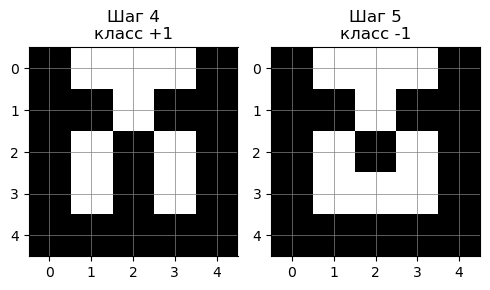

In [11]:

# Ищем пару СОСЕДНИХ изображений на пути, которые относятся к разным
# классам (по выходу нейрона) -- по построению они отличаются ровно на 1 пиксель

flip_index = None
for k in range(len(morph_outputs) - 1):
    if morph_outputs[k] != morph_outputs[k + 1]:
        flip_index = k
        break

if flip_index is not None:
    img_a = morph_path[flip_index]
    img_b = morph_path[flip_index + 1]
    print(f"Найдена пара изображений (шаги {flip_index} и {flip_index+1}),")
    print(f"отличающихся на {hamming_distance(img_a.flatten(), img_b.flatten())} пиксель,")
    print(f"и относящихся к разным классам: {morph_outputs[flip_index]:+.0f} и {morph_outputs[flip_index+1]:+.0f}")

    fig, axes = plt.subplots(1, 2, figsize=(5, 3))
    axes[0].imshow(img_a, cmap="gray_r", vmin=0, vmax=1)
    axes[0].set_title(f"Шаг {flip_index}\nкласс {morph_outputs[flip_index]:+.0f}")
    axes[1].imshow(img_b, cmap="gray_r", vmin=0, vmax=1)
    axes[1].set_title(f"Шаг {flip_index+1}\nкласс {morph_outputs[flip_index+1]:+.0f}")
    for ax in axes:
        ax.set_xticks(range(5)); ax.set_yticks(range(5))
        ax.grid(color="gray", linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("На данном пути перехода нейрон не меняет класс ни разу (граница не найдена).")


In [12]:

# Полная таблица мер сходства для каждого изображения пути перехода
print(f"{'Шаг':>4} | {'Хэмм.Ш1':>8} {'Хэмм.М1':>8} | {'Косин.Ш1':>9} {'Косин.М1':>9} | {'net':>8} {'класс':>6}")
print("-" * 66)
ref_sh = to_bipolar_vector(Sh_1)
ref_m = to_bipolar_vector(M_1)
for k, (v, n, y) in enumerate(zip(morph_vectors, morph_nets, morph_outputs)):
    rep = similarity_report(v, ref_sh, ref_m, "Ш1", "М1")
    print(f"{k:>4} | {rep['Хэмминг до Ш1']:>8} {rep['Хэмминг до М1']:>8} | "
          f"{rep['Косинус до Ш1']:>9} {rep['Косинус до М1']:>9} | {n:>8.2f} {y:>+6.0f}")


 Шаг |  Хэмм.Ш1  Хэмм.М1 |  Косин.Ш1  Косин.М1 |      net  класс
------------------------------------------------------------------
   0 |        0        8 |       1.0      0.36 |    28.00     +1
   1 |        1        7 |      0.92      0.44 |    24.00     +1
   2 |        2        6 |      0.84      0.52 |    16.00     +1
   3 |        3        5 |      0.76       0.6 |     8.00     +1
   4 |        4        4 |      0.68      0.68 |     0.00     +1
   5 |        5        3 |       0.6      0.76 |    -4.00     -1
   6 |        6        2 |      0.52      0.84 |   -12.00     -1
   7 |        7        1 |      0.44      0.92 |   -20.00     -1
   8 |        8        0 |      0.36       1.0 |   -28.00     -1



### 1.5 Коррекция порогов функции активации

Если один из классов классифицируется неуверенно (net близок к 0 для
эталонных образов), порог можно сместить так, чтобы он проходил ровно
посередине между средними значениями net двух классов.


In [13]:

# Средние значения net input для каждого класса (биполярное представление)
net_class1 = np.array([net_input(w_bip, b_bip, x) for x in X_bip[:2]])  # Ш1, Ш2
net_class2 = np.array([net_input(w_bip, b_bip, x) for x in X_bip[2:]])  # М1, М2

mean_net_class1 = net_class1.mean()
mean_net_class2 = net_class2.mean()

# Оптимальный порог -- посередине между средними значениями net двух классов
optimal_threshold = (mean_net_class1 + mean_net_class2) / 2

print(f"Среднее net для класса 1 (Ш): {mean_net_class1:.2f}")
print(f"Среднее net для класса 2 (М): {mean_net_class2:.2f}")
print(f"Скорректированный порог активации: {optimal_threshold:.2f}")

# Повторная проверка классификации с новым порогом
print()
for name, x in zip(["Ш1", "Ш2", "М1", "М2"], X_bip):
    net = net_input(w_bip, b_bip, x)
    y = activation_bipolar(net, threshold=optimal_threshold)
    print(f"{name}: net = {net:8.2f}  ->  выход (со скорр. порогом) = {y:+.0f}")


Среднее net для класса 1 (Ш): 26.00
Среднее net для класса 2 (М): -26.00
Скорректированный порог активации: 0.00

Ш1: net =    28.00  ->  выход (со скорр. порогом) = +1
Ш2: net =    24.00  ->  выход (со скорр. порогом) = +1
М1: net =   -28.00  ->  выход (со скорр. порогом) = -1
М2: net =   -24.00  ->  выход (со скорр. порогом) = -1



## Часть 2. Исследование другой функции активации

В качестве индивидуального варианта функции активации выбрана
**сигмоидальная (логистическая) функция**, дополнительно расширенная
до "мягкой" трехзонной интерпретации с помощью точек $Q_1$ и $Q_2$.

### 2.1 Настройка функции активации по точкам Q1, Q2

Отрезок между средними суммарными входными сигналами эталонных
изображений разных классов делится на 3 равные части. Полученные
точки деления $Q_1$ и $Q_2$ используются для настройки функции активации:

- $net \le Q_1$  →  уверенно класс 2 («М»),
- $Q_1 < net < Q_2$  →  зона неопределенности (переходная область),
- $net \ge Q_2$  →  уверенно класс 1 («Ш»).


In [14]:

# Средние суммарные входные сигналы (net) эталонных изображений разных классов
# уже вычислены выше: mean_net_class1 (класс "Ш"), mean_net_class2 (класс "М")

low, high = sorted([mean_net_class1, mean_net_class2])
segment_length = high - low
Q1 = low + segment_length / 3
Q2 = low + 2 * segment_length / 3

print(f"Границы отрезка: [{low:.2f}, {high:.2f}]")
print(f"Точка Q1 = {Q1:.2f}")
print(f"Точка Q2 = {Q2:.2f}")


Границы отрезка: [-26.00, 26.00]
Точка Q1 = -8.67
Точка Q2 = 8.67


In [15]:

def sigmoid(net, center, steepness=1.0):
    '''Стандартная сигмоидальная (логистическая) функция активации'''
    return 1.0 / (1.0 + np.exp(-steepness * (net - center)))

def activation_custom(net, q1, q2):
    '''
    Индивидуальная функция активации, настроенная по точкам Q1, Q2:
    - ниже Q1  -> уверенный класс 2 (значение близко к -1)
    - выше Q2  -> уверенный класс 1 (значение близко к +1)
    - между Q1 и Q2 -> плавный сигмоидальный переход (зона неопределенности)
    Возвращает значение в диапазоне (-1, 1), а также текстовую метку зоны.
    '''
    center = (q1 + q2) / 2.0
    # крутизна подобрана так, чтобы сигмоида проходила через ~0.12 и ~0.88 в Q1 и Q2
    steepness = 4.0 / max(q2 - q1, 1e-6)
    s = sigmoid(net, center, steepness)          # значение в (0, 1)
    value = 2 * s - 1                             # переводим в диапазон (-1, 1)

    if net <= q1:
        zone = "класс 2 (М)"
    elif net >= q2:
        zone = "класс 1 (Ш)"
    else:
        zone = "зона неопределенности"
    return value, zone


In [16]:

# Проверка новой функции активации на эталонных изображениях
print(f"{'Образ':>6} | {'net':>8} | {'выход f(net)':>12} | {'зона':>22}")
print("-" * 58)
for name, x in zip(["Ш1", "Ш2", "М1", "М2"], X_bip):
    net = net_input(w_bip, b_bip, x)
    value, zone = activation_custom(net, Q1, Q2)
    print(f"{name:>6} | {net:>8.2f} | {value:>12.3f} | {zone:>22}")


 Образ |      net | выход f(net) |                   зона
----------------------------------------------------------
    Ш1 |    28.00 |        0.997 |            класс 1 (Ш)
    Ш2 |    24.00 |        0.992 |            класс 1 (Ш)
    М1 |   -28.00 |       -0.997 |            класс 2 (М)
    М2 |   -24.00 |       -0.992 |            класс 2 (М)



### 2.2 Поиск изображений, попадающих в зону [Q1, Q2]

Снова используем путь попиксельного перехода от буквы «Ш» к букве «М»
(построенный в части 1) и для каждого изображения проверяем, попадает
ли его net input в отрезок $[Q_1, Q_2]$.


In [17]:

print(f"{'Шаг':>4} | {'net':>8} | {'f(net)':>8} | {'в [Q1,Q2]?':>11} | "
      f"{'Хэмм.Ш1':>8} {'Хэмм.М1':>8} | {'Косин.Ш1':>9} {'Косин.М1':>9}")
print("-" * 90)

images_in_zone = []
for k, (img, v, n) in enumerate(zip(morph_path, morph_vectors, morph_nets)):
    value, zone = activation_custom(n, Q1, Q2)
    in_zone = Q1 <= n <= Q2
    rep = similarity_report(v, ref_sh, ref_m, "Ш1", "М1")
    marker = "ДА" if in_zone else "-"
    print(f"{k:>4} | {n:>8.2f} | {value:>8.3f} | {marker:>11} | "
          f"{rep['Хэмминг до Ш1']:>8} {rep['Хэмминг до М1']:>8} | "
          f"{rep['Косинус до Ш1']:>9} {rep['Косинус до М1']:>9}")
    if in_zone:
        images_in_zone.append((k, img, n, value))

print(f"\nВсего изображений в зоне неопределенности [Q1, Q2]: {len(images_in_zone)}")


 Шаг |      net |   f(net) |  в [Q1,Q2]? |  Хэмм.Ш1  Хэмм.М1 |  Косин.Ш1  Косин.М1
------------------------------------------------------------------------------------------
   0 |    28.00 |    0.997 |           - |        0        8 |       1.0      0.36
   1 |    24.00 |    0.992 |           - |        1        7 |      0.92      0.44
   2 |    16.00 |    0.951 |           - |        2        6 |      0.84      0.52
   3 |     8.00 |    0.727 |          ДА |        3        5 |      0.76       0.6
   4 |     0.00 |    0.000 |          ДА |        4        4 |      0.68      0.68
   5 |    -4.00 |   -0.431 |          ДА |        5        3 |       0.6      0.76
   6 |   -12.00 |   -0.882 |           - |        6        2 |      0.52      0.84
   7 |   -20.00 |   -0.980 |           - |        7        1 |      0.44      0.92
   8 |   -28.00 |   -0.997 |           - |        8        0 |      0.36       1.0

Всего изображений в зоне неопределенности [Q1, Q2]: 3


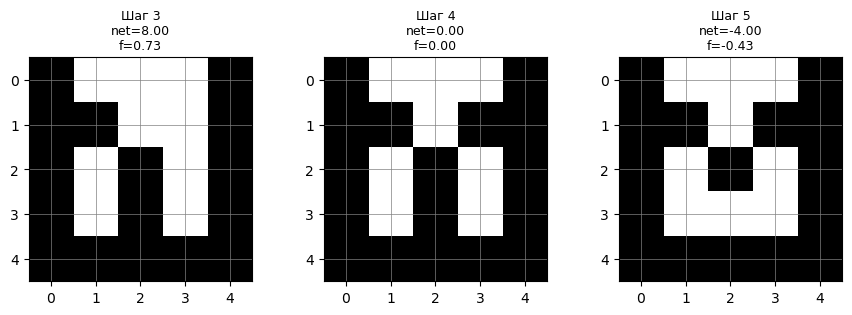

In [18]:

# Визуализация изображений, попавших в зону неопределенности [Q1, Q2]
if images_in_zone:
    n_imgs = len(images_in_zone)
    fig, axes = plt.subplots(1, n_imgs, figsize=(3 * n_imgs, 3))
    if n_imgs == 1:
        axes = [axes]
    for ax, (k, img, n, value) in zip(axes, images_in_zone):
        ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
        ax.set_title(f"Шаг {k}\nnet={n:.2f}\nf={value:.2f}", fontsize=9)
        ax.set_xticks(range(5)); ax.set_yticks(range(5))
        ax.grid(color="gray", linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Ни одно изображение перехода не попало в зону [Q1, Q2] -- "
          "переход между классами происходит слишком резко (одним пикселем).")


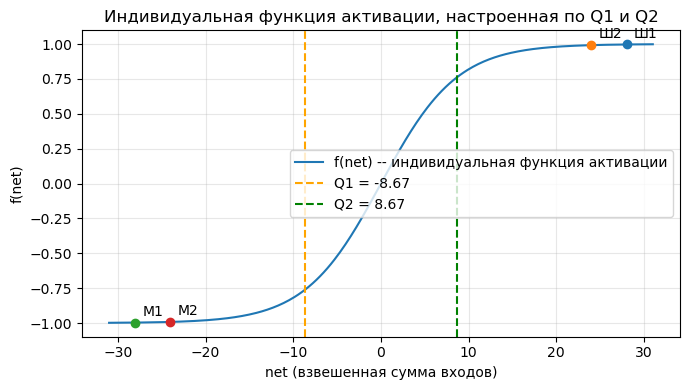

In [19]:

# Дополнительная иллюстрация: график сигмоидальной функции активации
# с отмеченными точками Q1 и Q2 и значениями net всех эталонных изображений

net_range = np.linspace(low - 5, high + 5, 300)
values = [activation_custom(n, Q1, Q2)[0] for n in net_range]

plt.figure(figsize=(7, 4))
plt.plot(net_range, values, label="f(net) -- индивидуальная функция активации")
plt.axvline(Q1, color="orange", linestyle="--", label=f"Q1 = {Q1:.2f}")
plt.axvline(Q2, color="green", linestyle="--", label=f"Q2 = {Q2:.2f}")

for name, x in zip(["Ш1", "Ш2", "М1", "М2"], X_bip):
    n = net_input(w_bip, b_bip, x)
    v, _ = activation_custom(n, Q1, Q2)
    plt.scatter([n], [v], zorder=5)
    plt.annotate(name, (n, v), textcoords="offset points", xytext=(5, 5))

plt.xlabel("net (взвешенная сумма входов)")
plt.ylabel("f(net)")
plt.title("Индивидуальная функция активации, настроенная по Q1 и Q2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Анализ полученных результатов

1. **Биполярное представление** сигналов дает нейрону, обученному по
   правилу Хебба, значительно более уверенное и симметричное разделение
   классов «Ш» и «М», чем бинарное представление — потому что в биполярном
   виде «пустые» (фоновые) пиксели тоже вносят вклад в обучение
   ($t \cdot(-1) \neq 0$), тогда как в бинарном представлении вклад
   фоновых пикселей равен нулю.
2. При попиксельном переходе от буквы «Ш» к букве «М» нейрон меняет
   решение о классе не постепенно, а в определенный момент (найдена пара
   соседних изображений, отличающихся всего на 1 пиксель, но
   относящихся к разным классам) — это говорит о наличии четкой линейной
   разделяющей гиперплоскости между классами.
3. Настройка индивидуальной (сигмоидальной) функции активации по точкам
   $Q_1$ и $Q_2$ позволяет выделить "зону неопределенности" — область
   входных сигналов, где решение нейрона нельзя считать уверенным. Для
   рассмотренного пути перехода число изображений, попавших в эту зону,
   отражает, насколько "резко" или "плавно" происходит смена класса.
4. Скорректированный порог активации (посередине между средними
   значениями net двух классов) улучшает устойчивость классификации
   образов, близких к границе между классами.
